In [8]:
import ufl
import gmsh
import adios4dolfinx
import numpy as np
import pyvista as pv
import dolfinx.io as dio

from dolfinx.nls.petsc import NewtonSolver
from dolfinx.fem.petsc import LinearProblem, NonlinearProblem
from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from basix.ufl import element, mixed_element


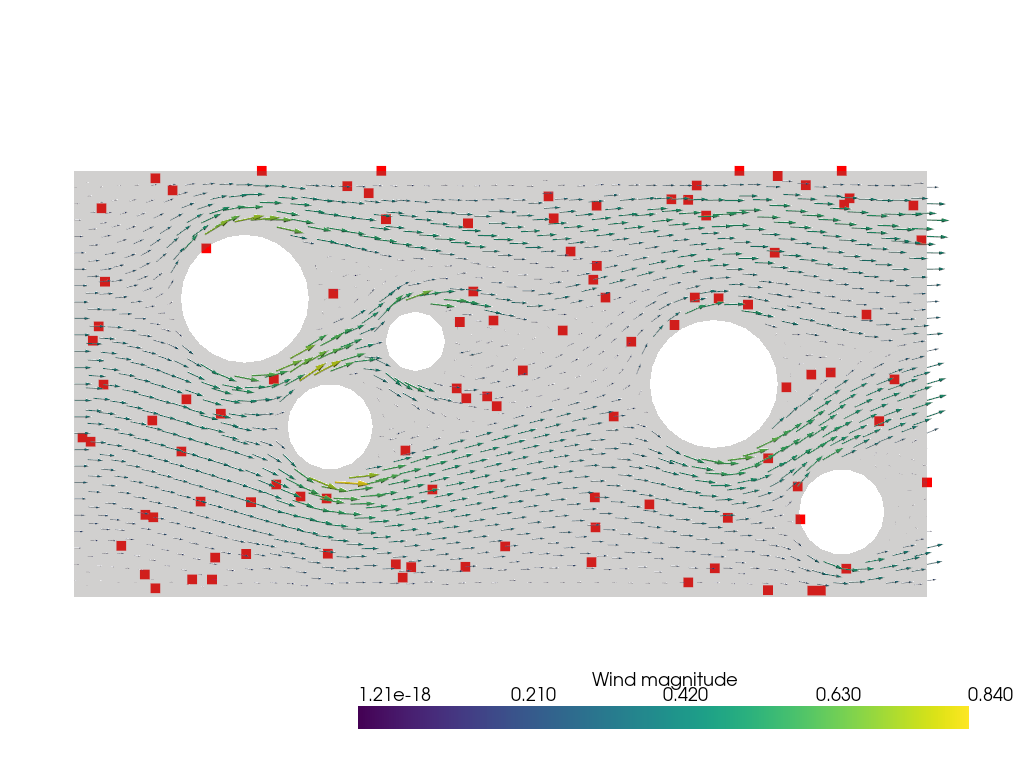

In [9]:
wind_file = Path("../wind_data/airflow_picard.bp")
domain = adios4dolfinx.read_mesh(wind_file, MPI.COMM_WORLD)
domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)

topology, cell_type, geom = plot.vtk_mesh(domain)
grid = pv.UnstructuredGrid(topology, cell_type, geom)

elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])
W = fem.functionspace(domain, mixed_elem)
W_u, map_u = W.sub(0).collapse() 
W_p, map_p = W.sub(1).collapse()

# Load true velocity fields in P2 and P1
u_true = fem.Function(W_u)
adios4dolfinx.read_function(wind_file, u_true, name="velocity_H2")

# Random P2 samples
coords_P2 = W_u.tabulate_dof_coordinates()
p = 100
rng = np.random.default_rng(1)
sample_ids = rng.choice(len(coords_P2), size=p, replace=False)

x_ids = sample_ids * 2
y_ids = sample_ids * 2 + 1
value_ids = np.stack((x_ids, y_ids)).T.flatten()

measured_fun = fem.Function(W_u)
measured_fun.x.array[:] = 0.0
measured_fun.x.array[value_ids] = u_true.x.array[value_ids]

# --- Prepare visualization of wind field and sampled points ---
sample_points_2d = coords_P2[sample_ids, :2]
sample_points_3d = np.column_stack((sample_points_2d, np.zeros(p)))

# Additional P1 space for wind visualization
V_vis = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1, shape=(2,))) 
u_true_vis = fem.Function(V_vis)
adios4dolfinx.read_function(wind_file, u_true_vis, name="velocity_H1")

wind2d = u_true_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

measured = pv.PolyData(sample_points_3d)

# --- Plot ---
pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind magnitude"})
pl.add_mesh(measured, color="red", point_size=10, label="Sample DOFs (P2)")
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

In [ ]:
# Define KKT space W x W
W_KKT = fem.functionspace(domain, mixed_element([elem_u, elem_p, elem_u, elem_p]))
w_kkt = fem.Function(W_KKT) 
u_sol, p_sol, lam_sol, mu_sol = ufl.split(w_kkt)

# Mask function for for selected measurements
sample_mask_fun = fem.Function(W_u)
sample_mask_fun.x.array[:] = 0.0
sample_mask_fun.x.array[value_ids] = 1.0

def misfit(u_c: ufl.core.expr.Expr, measured_fun: fem.Function, mask_c: fem.Function, weight=1.0):
    diff = ufl.as_vector([mask_c * (u_c[i] - measured_fun[i]) for i in range(u_c.ufl_shape[0])])
    
    return 0.5 * weight * ufl.inner(diff, diff) * ufl.dx

nu = fem.Constant(domain, 1.5e-4)

pde_term = (
    nu * ufl.inner(ufl.grad(u_sol), ufl.grad(lam_sol))
    + ufl.inner(ufl.dot(u_sol, ufl.grad(u_sol)), lam_sol)
    - ufl.inner(p_sol, ufl.div(lam_sol))
    + ufl.inner(ufl.div(u_sol), mu_sol)
) * ufl.dx 

gamma = 1e-3
reg = 0.5 * gamma * ufl.inner(ufl.grad(u_sol), ufl.grad(u_sol)) * ufl.dx
J = misfit(u_sol, measured_fun, sample_mask_fun) + reg 

Lagrange = J + pde_term

# Test functions
dw_kkt = ufl.TestFunction(W_KKT)
du, dp, dlam, dmu = ufl.split(dw_kkt)

# Compute variations
dL_du = ufl.derivative(Lagrange, u_sol, du)
dL_dp = ufl.derivative(Lagrange, p_sol, dp)
dL_dlam = ufl.derivative(Lagrange, lam_sol, dlam)
dL_dmu = ufl.derivative(Lagrange, mu_sol, dmu)

# Total residual
F_kkt = dL_du + dL_dp + dL_dlam + dL_dmu

dolfinx.fem.function.Function

In [12]:
# Load facet tags to assign boundary conditions
meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()

_, _, facet_tags = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

print(name_to_id)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}


In [13]:
W_KKT0 = W_KKT.sub(0)
KKT_u, KKT_u_map = W_KKT0.collapse()
u_D_no_slip = fem.Function(KKT_u)
u_D_no_slip.x.array[:] = 0.1
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological((W_KKT0, KKT_u), KKT_u.mesh.topology.dim - 1, dofs_local)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs, W_KKT0)


W_KKT1 = W_KKT.sub(1)
KKT_p, KKT_p_map = W_KKT1.collapse()
dofs_p_point = fem.locate_dofs_geometrical(
    (W_KKT1, KKT_p), lambda x: np.isclose(x[0], 0.0) & np.isclose(x[1], 0.0))

bc_zero_p_point = fem.dirichletbc(1.0, dofs_p_point[0], W_KKT1)

In [ ]:
w_kkt_trial = ufl.TrialFunction(W_KKT)
J = ufl.derivative(F_kkt, w_kkt, w_kkt_trial)

w_kkt.x.array[:] = 0.0

nl_problem = NonlinearProblem(F_kkt, w_kkt, [bc_no_slip, bc_zero_p_point], J)
solver = NewtonSolver(MPI.COMM_WORLD, nl_problem)

num_its, converged = solver.solve(w_kkt)
# try picard instead -> linearize pde + iteration
# altern.: try stokes instead of NS, is the problem then linear?? i thiunk o

RuntimeError: Newton solver did not converge because maximum number of iterations reached